We check the code for simulation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
from scipy.special import kv, gamma
import scipy.linalg
from gaussian_crossings import simulate_gaussian_process_fft, simulate_gaussian_process_cholesky

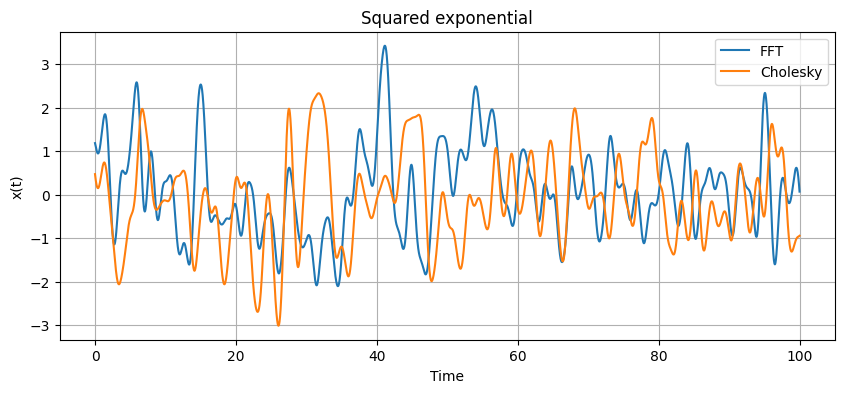

In [2]:
# For a type of Gaussian process with a squared-exponential autocorrelation function
def r_squared_exp(t, tau, sigma):
    return sigma ** 2 * torch.exp(- (t/ tau) ** 2)

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
dt = 0.01   # Time discretization step
tau = 1.0   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = simulate_gaussian_process_fft(r_squared_exp, T, dt, tau=tau, sigma=sigma)
t1, x1 = simulate_gaussian_process_cholesky(r_squared_exp, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Squared exponential')
plt.legend()
plt.grid(True)
plt.show()

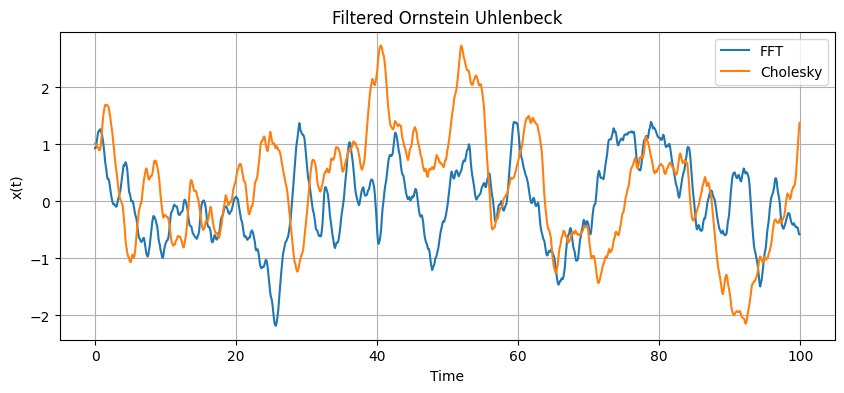

In [3]:
# For a filtered Ornstein-Uhlenbeck process, we have
def r_filtered_OU(t, sigma, tau_e, tau_f):
    chi = tau_f / tau_e
    return (sigma ** 2 / (1 - chi ** 2)) * (torch.exp(- torch.abs(t) / tau_e) - chi * torch.exp(- torch.abs(t) / tau_f))

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_e = 1.0   # Correlation decay parameter
tau_f = 0.9   # Correlation decay parameter
dt = 0.1 * min(tau_e, tau_f)   # Time discretization step
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = simulate_gaussian_process_fft(r_filtered_OU, T, dt, sigma=sigma, tau_e=tau_e, tau_f=tau_f)
t1, x1 = simulate_gaussian_process_cholesky(r_filtered_OU, T, dt, sigma=sigma, tau_e=tau_e, tau_f=tau_f)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Filtered Ornstein Uhlenbeck')
plt.legend()
plt.grid(True)
plt.show()

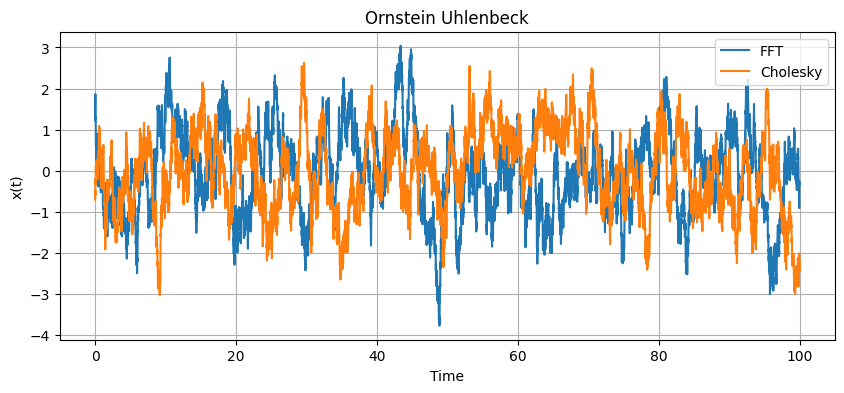

In [4]:
# For a Ornstein-Uhlenbeck process, we have
def r_OU(t, sigma, tau_e):
    return sigma ** 2  * (torch.exp(- torch.abs(t) / tau_e))

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_e = 1.0   # Correlation decay parameter
dt = 0.01
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = simulate_gaussian_process_fft(r_OU, T, dt, sigma=sigma, tau_e=tau_e)
t1, x1 = simulate_gaussian_process_cholesky(r_OU, T, dt, sigma=sigma, tau_e=tau_e)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Ornstein Uhlenbeck')
plt.legend()
plt.grid(True)
plt.show()

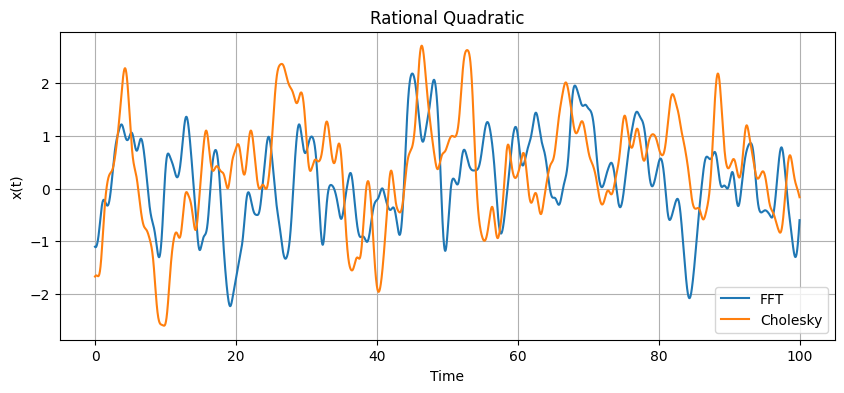

In [5]:
def r_rational_quadratic(t, tau, sigma, alpha):
    """
    Rational quadratic autocorrelation function.

    Parameters:
        t (array-like): Time differences.
        tau (float): Length-scale parameter.
        sigma (float): Standard deviation (amplitude) of the process.
        alpha (float): Shape parameter controlling the relative weighting of different scales.

    Returns:
        array-like: Autocorrelation values at times t.
    """
    return sigma ** 2 * (1 + (t / tau) ** 2 / (2 * alpha)) ** (-alpha)

# Set simulation parameters.
T = 100.0     # Total simulation time
dt = 0.01     # Time discretization step
tau = 1.0     # Length-scale parameter
sigma = 1.0   # Standard deviation of the process
alpha = 1.5   # Shape parameter of the rational quadratic function

# Generate a sample path of the Gaussian process.
t, x = simulate_gaussian_process_fft(r_rational_quadratic, T, dt, tau=tau, sigma=sigma, alpha=alpha)
t1, x1 = simulate_gaussian_process_cholesky(r_rational_quadratic, T, dt, tau=tau, sigma=sigma, alpha=alpha)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Rational Quadratic')
plt.legend()
plt.grid(True)
plt.show()

/var/folders/n7/dvsmt08j14310vr4k9jmj3s80000gn/T/ipykernel_4070/2861017034.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corr[nonzero] = sigma**2 * (2**(1 - nu) / gamma(nu)) * (factor[nonzero]**nu) * kv(nu, factor[nonzero])


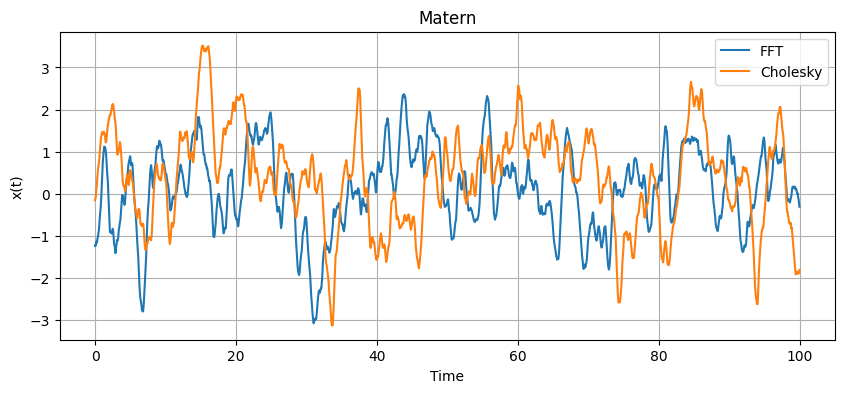

In [7]:
def r_matern(t, tau, sigma, nu):
    """
    Matern autocorrelation function.

    Parameters:
        t (array-like): Time differences.
        tau (float): Length-scale parameter.
        sigma (float): Standard deviation (amplitude) of the process.
        nu (float): Smoothness parameter (nu > 0).

    Returns:
        array-like: Autocorrelation values at times t.
    """
    t_abs = torch.abs(t)
    factor = np.sqrt(2 * nu) * t_abs / tau
    corr = torch.zeros_like(t_abs)
    # Handle the t=0 case to avoid division by zero (the limit is sigma^2).
    nonzero = t_abs > 0
    corr[nonzero] = sigma**2 * (2**(1 - nu) / gamma(nu)) * (factor[nonzero]**nu) * kv(nu, factor[nonzero])
    corr[~nonzero] = sigma**2
    return corr

# Set simulation parameters.
T = 100.0    # Total simulation time
dt = 0.01    # Time discretization step
tau = 1.0    # Length-scale parameter
sigma = 1.0  # Standard deviation of the process
nu = 1.5     # Smoothness parameter for the Matern function

# Generate a sample path of the Gaussian process.
t, x = simulate_gaussian_process_fft(r_matern, T, dt, tau=tau, sigma=sigma, nu=nu)
t1, x1 = simulate_gaussian_process_cholesky(r_matern, T, dt, tau=tau, sigma=sigma, nu=nu)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Matern')
plt.legend()
plt.grid(True)
plt.show()